# 1.wfdb 설치

In [1]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 44.9 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.3 which is incompatible.
db-dtypes 1.6.0 requires pandas<3.0.0,>=1.5.3, but you have pandas 3.0.3 which is incompatible.
gradio 5.50.0 requires pandas<3.0,>=1.0, but you have pandas 3.0.3 which is incompatible.


#2.모든 환자 데이터 추출 및 비율 확인

#부정맥데이터/정상데이터의 비율을 맞추기 위함

In [3]:
import wfdb
import numpy as np

# =========================
# MIT-BIH 전체 record
# =========================
records = [
    "100", "101", "102", "103", "104",
    "105", "106", "107", "108", "109",
    "111", "112", "113", "114", "115",
    "116", "117", "118", "119", "121",
    "122", "123", "124",

    "200", "201", "202", "203", "205",
    "207", "208", "209", "210", "212",
    "213", "214", "215", "217", "219",
    "220", "221", "222", "223", "228",
    "230", "231", "232", "233", "234"
]

# =========================
# 전체 결과 저장 변수
# =========================
total_normal = 0
total_arrhythmia = 0

# =========================
# Record 반복
# =========================
for record_name in records:

    # =========================
    # 데이터 로드
    # =========================
    record = wfdb.rdrecord(
        record_name,
        pn_dir="mitdb/1.0.0"
    )

    annotation = wfdb.rdann(
        record_name,
        "atr",
        pn_dir="mitdb/1.0.0"
    )

    signal = record.p_signal[:, 0]
    fs = record.fs

    samples = annotation.sample
    symbols = annotation.symbol

    # =========================
    # 10초 window 설정
    # =========================
    window_sec = 10
    window_size = int(fs * window_sec)

    total_windows = len(signal) // window_size

    # =========================
    # 50개 window 선택
    # =========================
    num_windows = 50

    indices = np.linspace(
        0,
        total_windows - 1,
        num_windows,
        dtype=int
    )

    # =========================
    # PVC Count 계산
    # =========================
    normal_count = 0
    arrhythmia_count = 0

    for idx in indices:

        start = idx * window_size
        end = start + window_size

        pvc_count = 0

        # window 내부 PVC 개수 계산
        for s, sym in zip(samples, symbols):

            if start <= s < end:

                if sym == 'V':
                    pvc_count += 1

        # =========================
        # 분류 기준
        # PVC 0~2개 → 정상
        # PVC 3개 이상 → 부정맥
        # =========================
        if pvc_count <= 2:
            normal_count += 1

        elif pvc_count >= 3:
            arrhythmia_count += 1

    # =========================
    # 전체 누적
    # =========================
    total_normal += normal_count
    total_arrhythmia += arrhythmia_count

    # =========================
    # 결과 출력
    # =========================
    print("=" * 60)
    print(f"Record : {record_name}")

    print(f"정상(0~2 PVC) : {normal_count}")
    print(f"부정맥(3+ PVC) : {arrhythmia_count}")

    print(f"최종 사용 가능 데이터 : {normal_count + arrhythmia_count}")

# =========================
# 전체 데이터 결과
# =========================
print("\n" + "=" * 60)
print("전체 데이터 결과")

print(f"전체 정상 데이터 : {total_normal}")
print(f"전체 부정맥 데이터 : {total_arrhythmia}")

print(f"전체 사용 가능 데이터 : {total_normal + total_arrhythmia}")
print("=" * 60)

Record : 100
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 101
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 102
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 103
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 104
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 105
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 106
정상(0~2 PVC) : 26
부정맥(3+ PVC) : 24
최종 사용 가능 데이터 : 50
Record : 107
정상(0~2 PVC) : 49
부정맥(3+ PVC) : 1
최종 사용 가능 데이터 : 50
Record : 108
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 109
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 111
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 112
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 113
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 114
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 115
정상(0~2 PVC) : 50
부정맥(3+ PVC) : 0
최종 사용 가능 데이터 : 50
Record : 116
정상(0~2 PVC) : 50
부정맥(3+ PV

#3.환자 5명 데이터 추출

#(200,208,210,214,221) 추출
#정상 128, 부정맥 122 총 250개의 데이터 값

In [11]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 사용할 환자 목록
# =========================
record_names = ["200", "208", "210", "214", "221"]

window_sec = 10
num_windows = 50

X = []
y = []
info = []

# 그래프 보고 싶으면 True
show_graph = False

# =========================
# 2. 환자별 데이터 추출
# =========================
for record_name in record_names:

    print(f"\n===== 환자 {record_name} 처리 시작 =====")

    record = wfdb.rdrecord(record_name, pn_dir="mitdb/1.0.0")
    annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb/1.0.0")

    signal = record.p_signal[:, 0]
    fs = record.fs

    samples = annotation.sample
    symbols = annotation.symbol


    # 10초 window 크기
    window_size = int(fs * window_sec)

    # 전체 window 개수
    total_windows = len(signal) // window_size

    # 50개 window 선택
    indices = np.linspace(
        0,
        total_windows - 1,
        num_windows,
        dtype=int
    )

    patient_normal = 0
    patient_arrhythmia = 0
    #window 반복
    for idx_num, idx in enumerate(indices):

        start = idx * window_size
        end = start + window_size

        segment = signal[start:end]

        # =========================
        # PVC 개수 세기
        # =========================
        pvc_count = 0

        for s, sym in zip(samples, symbols):

            if start <= s < end:

                if sym == 'V':
                    pvc_count += 1

        # =========================
        # PVC 0~2개 -> 정상
        # PVC 3개 이상 -> 부정맥
        # =========================
        if pvc_count <= 2:
          label = 0
          patient_normal += 1

        else:
          label = 1
          patient_arrhythmia += 1

        # =========================
        # 저장
        # =========================
        X.append(segment)
        y.append(label)

        info.append({
            "record": record_name,
            "window_number": idx_num + 1,
            "start_sample": start,
            "end_sample": end,
            "pvc_count": pvc_count,
            "label": label
        })

        # =========================
        # 그래프 출력
        # =========================
        if show_graph:

            time_axis = np.arange(len(segment)) / fs

            plt.figure(figsize=(12, 4))
            plt.plot(time_axis, segment)

            plt.title(
                f"Record {record_name} | "
                f"Window {idx_num+1}/{num_windows} | "
                f"PVC Count: {pvc_count} | "
                f"Label: {'Normal' if label == 0 else 'Arrhythmia'}"
            )

            plt.xlabel("Time (s)")
            plt.ylabel("ECG")
            plt.grid(True)

            plt.show()

    # =========================
    # 환자별 결과 출력
    # =========================
    print(f"환자 {record_name} 정상 개수: {patient_normal}")
    print(f"환자 {record_name} 부정맥 개수: {patient_arrhythmia}")

# =========================
# 3. numpy 변환
# =========================
X = np.array(X)
y = np.array(y)

print("\n===== 전체 결과 =====")

print("최종 저장 데이터 수:", len(X))
print("정상 개수:", np.sum(y == 0))
print("부정맥 개수:", np.sum(y == 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 4. npy 저장
# =========================
np.save("X_ecg.npy", X)
np.save("y_ecg.npy", y)

# =========================
# 5. CSV 저장
# =========================
df_X = pd.DataFrame(X)
df_info = pd.DataFrame(info)

df = pd.concat([df_info, df_X], axis=1)

df.to_csv(
    "ecg_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================
# 저장 완료
# =========================
print("\n저장 완료")

print("X_ecg.npy 저장 완료")
print("y_ecg.npy 저장 완료")
print("ecg_dataset.csv 저장 완료")


===== 환자 200 처리 시작 =====
환자 200 정상 개수: 9
환자 200 부정맥 개수: 41

===== 환자 208 처리 시작 =====
환자 208 정상 개수: 4
환자 208 부정맥 개수: 46

===== 환자 210 처리 시작 =====
환자 210 정상 개수: 45
환자 210 부정맥 개수: 5

===== 환자 214 처리 시작 =====
환자 214 정상 개수: 40
환자 214 부정맥 개수: 10

===== 환자 221 처리 시작 =====
환자 221 정상 개수: 30
환자 221 부정맥 개수: 20

===== 전체 결과 =====
최종 저장 데이터 수: 250
정상 개수: 128
부정맥 개수: 122
X shape: (250, 3600)
y shape: (250,)

저장 완료
X_ecg.npy 저장 완료
y_ecg.npy 저장 완료
ecg_dataset.csv 저장 완료


#추가 데이터 파일 추출(csv)

In [5]:
import wfdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. 사용할 환자 목록
# =========================
record_names = ["213", "219"]

window_sec = 10
num_windows = 50

X = []
y = []
info = []

# 그래프 보고 싶으면 True
show_graph = False

# =========================
# 2. 환자별 데이터 추출
# =========================
for record_name in record_names:

    print(f"\n===== 환자 {record_name} 처리 시작 =====")

    record = wfdb.rdrecord(record_name, pn_dir="mitdb/1.0.0")
    annotation = wfdb.rdann(record_name, "atr", pn_dir="mitdb/1.0.0")

    signal = record.p_signal[:, 0]
    fs = record.fs

    samples = annotation.sample
    symbols = annotation.symbol

    # =========================
    # 10초 window 크기
    # =========================
    window_size = int(fs * window_sec)

    # 전체 window 개수
    total_windows = len(signal) // window_size

    # 50개 window 선택
    indices = np.linspace(
        0,
        total_windows - 1,
        num_windows,
        dtype=int
    )

    patient_normal = 0
    patient_arrhythmia = 0

    # =========================
    # window 반복
    # =========================
    for idx_num, idx in enumerate(indices):

        start = idx * window_size
        end = start + window_size

        segment = signal[start:end]

        # =========================
        # PVC 개수 세기
        # =========================
        pvc_count = 0

        for s, sym in zip(samples, symbols):

            if start <= s < end:

                if sym == 'V':
                    pvc_count += 1

        # =========================
        # PVC 0~2개 -> 정상
        # PVC 3개 이상 -> 부정맥
        # =========================
        if pvc_count <= 2:
          label = 0
          patient_normal += 1

        else:
          label = 1
          patient_arrhythmia += 1

        # =========================
        # 저장
        # =========================
        X.append(segment)
        y.append(label)

        info.append({
            "record": record_name,
            "window_number": idx_num + 1,
            "start_sample": start,
            "end_sample": end,
            "pvc_count": pvc_count,
            "label": label
        })

        # =========================
        # 그래프 출력
        # =========================
        if show_graph:

            time_axis = np.arange(len(segment)) / fs

            plt.figure(figsize=(12, 4))
            plt.plot(time_axis, segment)

            plt.title(
                f"Record {record_name} | "
                f"Window {idx_num+1}/{num_windows} | "
                f"PVC Count: {pvc_count} | "
                f"Label: {'Normal' if label == 0 else 'Arrhythmia'}"
            )

            plt.xlabel("Time (s)")
            plt.ylabel("ECG")
            plt.grid(True)

            plt.show()

    # =========================
    # 환자별 결과 출력
    # =========================
    print(f"환자 {record_name} 정상 개수: {patient_normal}")
    print(f"환자 {record_name} 부정맥 개수: {patient_arrhythmia}")

# =========================
# 3. numpy 변환
# =========================
X = np.array(X)
y = np.array(y)

print("\n===== 전체 결과 =====")

print("최종 저장 데이터 수:", len(X))
print("정상 개수:", np.sum(y == 0))
print("부정맥 개수:", np.sum(y == 1))

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 4. npy 저장
# =========================
np.save("X_ecg.npy", X)
np.save("y_ecg.npy", y)

# =========================
# 5. CSV 저장
# =========================
df_X = pd.DataFrame(X)
df_info = pd.DataFrame(info)

df = pd.concat([df_info, df_X], axis=1)

df.to_csv(
    "ecg_dataset.csv",
    index=False,
    encoding="utf-8-sig"
)

# =========================
# 저장 완료
# =========================
print("\n저장 완료")

print("X_ecg.npy 저장 완료")
print("y_ecg.npy 저장 완료")
print("ecg_dataset.csv 저장 완료")


===== 환자 213 처리 시작 =====
환자 213 정상 개수: 44
환자 213 부정맥 개수: 6

===== 환자 219 처리 시작 =====
환자 219 정상 개수: 50
환자 219 부정맥 개수: 0

===== 전체 결과 =====
최종 저장 데이터 수: 100
정상 개수: 94
부정맥 개수: 6
X shape: (100, 3600)
y shape: (100,)

저장 완료
X_ecg.npy 저장 완료
y_ecg.npy 저장 완료
ecg_dataset.csv 저장 완료


#4.모델링 파트(기본 모델 생성)

In [6]:
import numpy as np
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    GlobalAveragePooling1D
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2

# ===============================
# 1. 데이터 로드
# ===============================
X = np.load("X_ecg.npy")
y = np.load("y_ecg.npy")

print("원본 X shape:", X.shape)
print("원본 y shape:", y.shape)

# ===============================
# 2. 샘플별 정규화
# ===============================
X = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# CNN 입력 형태: (샘플 수, 길이, 채널)
X = X.reshape(X.shape[0], X.shape[1], 1)

print("변환 후 X shape:", X.shape)

# ===============================
# 3. train / test 분리
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("학습 데이터:", X_train.shape)
print("테스트 데이터:", X_test.shape)

# ===============================
# 4. class weight
# ===============================
classes = np.unique(y_train)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    0: weights[0],
    1: weights[1]
}

print("class_weight:", class_weight)

# ===============================
# 5. CNN 모델 생성
# ===============================
model = Sequential()

model.add(
    Conv1D(
        filters=16,
        kernel_size=21,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001),
        input_shape=(X.shape[1], 1)
    )
)
model.add(MaxPooling1D(pool_size=8))
model.add(Dropout(0.2))

model.add(
    Conv1D(
        filters=32,
        kernel_size=15,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001)
    )
)
model.add(MaxPooling1D(pool_size=4))
model.add(Dropout(0.25))

model.add(
    Conv1D(
        filters=64,
        kernel_size=9,
        activation="relu",
        padding="same",
        kernel_regularizer=l2(0.001)
    )
)
model.add(MaxPooling1D(pool_size=4))
model.add(Dropout(0.3))

model.add(GlobalAveragePooling1D())

model.add(
    Dense(
        32,
        activation="relu",
        kernel_regularizer=l2(0.001)
    )
)
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

# ===============================
# 6. 모델 컴파일
# ===============================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# ===============================
# 7. 콜백 설정
# ===============================
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=0.00001
)

# ===============================
# 8. 모델 학습
# ===============================
history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weight,
    verbose=1
)

# ===============================
# 9. 예측 확률
# ===============================
y_prob = model.predict(X_test).flatten()

# ===============================
# 10. threshold별 성능 비교
# ===============================
thresholds = [0.4, 0.45, 0.5, 0.55, 0.6, 0.65]

best_acc = 0
best_threshold = 0.5
best_pred = None

for t in thresholds:
    y_pred = (y_prob >= t).astype(int)
    acc = accuracy_score(y_test, y_pred)

    print("\n==============================")
    print(f"Threshold: {t}")
    print("Accuracy:", acc)
    print("Confusion Matrix")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report")
    print(classification_report(y_test, y_pred, zero_division=0))

    if acc > best_acc:
        best_acc = acc
        best_threshold = t
        best_pred = y_pred

# ===============================
# 11. 최종 결과 출력
# ===============================
print("\n==============================")
print("최고 Threshold:", best_threshold)
print("최고 정확도:", best_acc)
print("==============================")

print("최종 Confusion Matrix")
print(confusion_matrix(y_test, best_pred))

print("최종 Classification Report")
print(classification_report(y_test, best_pred, zero_division=0))

# ===============================
# 12. 모델 저장
# ===============================
model.save("ecg_cnn_10sec_tuned.keras")

print("\n모델 저장 완료")
print("ecg_cnn_10sec_tuned.keras 저장 완료")

원본 X shape: (100, 3600)
원본 y shape: (100,)
변환 후 X shape: (100, 3600, 1)
학습 데이터: (80, 3600, 1)
테스트 데이터: (20, 3600, 1)
class_weight: {0: np.float64(0.5333333333333333), 1: np.float64(8.0)}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 3600, 16)       │           352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 450, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 450, 16)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 450, 32)        │         7,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 112, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 112, 64)        │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,673 (112.00 KB)

 Trainable params: 28,673 (112.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - accuracy: 0.5625 - loss: 0.7503 - val_accuracy: 0.8750 - val_loss: 0.7548 - learning_rate: 3.0000e-04
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7344 - loss: 0.7294 - val_accuracy: 0.8750 - val_loss: 0.7312 - learning_rate: 3.0000e-04
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8750 - loss: 0.6758 - val_accuracy: 0.8750 - val_loss: 0.7109 - learning_rate: 3.0000e-04
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8594 - loss: 0.7300 - val_accuracy: 0.8750 - val_loss: 0.7030 - learning_rate: 3.0000e-04
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9062 - loss: 0.7617 - val_accuracy: 0.8750 - val_loss: 0.6854 - learning_rate: 3.0000e-04
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8906 - loss: 0.6883 - val_accuracy: 0.8750 - val_loss: 0.7168 - learning_rate: 3.0000e-04
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.7188 - loss:

In [7]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, y_prob)

print("\nAUC:", auc)


AUC: 0.631578947368421


# 5.모델 5개 비교

원본 X shape: (250, 3600)
원본 y shape: (250,)
변환 X shape: (250, 3600, 1)
Class Weight: {np.int64(0): np.float64(0.9803921568627451), np.int64(1): np.float64(1.0204081632653061)}

========== Model 1 Baseline ==========


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 51ms/step - accuracy: 0.5188 - loss: 0.8057 - val_accuracy: 0.3750 - val_loss: 0.8166 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5188 - loss: 0.7989 - val_accuracy: 0.3750 - val_loss: 0.8028 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5125 - loss: 0.7908 - val_accuracy: 0.3750 - val_loss: 0.7980 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5938 - loss: 0.7758 - val_accuracy: 0.4000 - val_loss: 0.7879 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.6000 - loss: 0.7696 - val_accuracy: 0.4000 - val_loss: 0.7939 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.5938 - loss: 0.7529 - val_accuracy: 0.5000 - val_loss: 0.7711 - learning_rate: 3.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 75ms/step - accuracy: 0.5562 - loss: 0.8721 - val_accuracy: 0.3750 - val_loss: 0.8896 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - accuracy: 0.5688 - loss: 0.8541 - val_accuracy: 0.3750 - val_loss: 0.8678 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5750 - loss: 0.8403 - val_accuracy: 0.3750 - val_loss: 0.8639 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.5500 - loss: 0.8334 - val_accuracy: 0.4250 - val_loss: 0.8448 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.5688 - loss: 0.8130 - val_accuracy: 0.4250 - val_loss: 0.8302 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6187 - loss: 0.8080 - val_accuracy: 0.6500 - val_loss: 0.7903 - learning_rate: 3.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6938 - los

...

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step - accuracy: 0.5250 - loss: 0.9084 - val_accuracy: 0.3750 - val_loss: 0.9122 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5375 - loss: 0.8776 - val_accuracy: 0.3750 - val_loss: 0.8955 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5562 - loss: 0.8720 - val_accuracy: 0.3750 - val_loss: 0.8872 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.5500 - loss: 0.8649 - val_accuracy: 0.3750 - val_loss: 0.8792 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.5938 - loss: 0.8476 - val_accuracy: 0.4250 - val_loss: 0.8599 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.6625 - loss: 0.8269 - val_accuracy: 0.4750 - val_loss: 0.8446 - learning_rate: 3.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy:

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 302ms/step - accuracy: 0.6438 - loss: 0.7990 - val_accuracy: 0.6500 - val_loss: 0.8467 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 160ms/step - accuracy: 0.7937 - loss: 0.6748 - val_accuracy: 0.6250 - val_loss: 0.8315 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.8250 - loss: 0.5920 - val_accuracy: 0.6250 - val_loss: 0.8291 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 197ms/step - accuracy: 0.8438 - loss: 0.5657 - val_accuracy: 0.6250 - val_loss: 0.8169 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 140ms/step - accuracy: 0.8375 - loss: 0.5315 - val_accuracy: 0.9000 - val_loss: 0.8063 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 116ms/step - accuracy: 0.8562 - loss: 0.5270 - val_accuracy: 0.9000 - val_loss: 0.8073 - learning_rate: 3.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 135ms/step - ac

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 130ms/step - accuracy: 0.6625 - loss: 0.9882 - val_accuracy: 0.6250 - val_loss: 1.0161 - learning_rate: 3.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.7812 - loss: 0.8278 - val_accuracy: 0.6250 - val_loss: 1.0040 - learning_rate: 3.0000e-04
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 148ms/step - accuracy: 0.8125 - loss: 0.7739 - val_accuracy: 0.3750 - val_loss: 1.0612 - learning_rate: 3.0000e-04
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 113ms/step - accuracy: 0.7937 - loss: 0.7555 - val_accuracy: 0.3750 - val_loss: 1.1083 - learning_rate: 3.0000e-04
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 137ms/step - accuracy: 0.8562 - loss: 0.7106 - val_accuracy: 0.3750 - val_loss: 1.1261 - learning_rate: 3.0000e-04
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.8375 - loss: 0.6673 - val_accuracy: 0.3750 - val_loss: 1.0906 - learning_rate: 3.0000e-04
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 146ms/step - acc

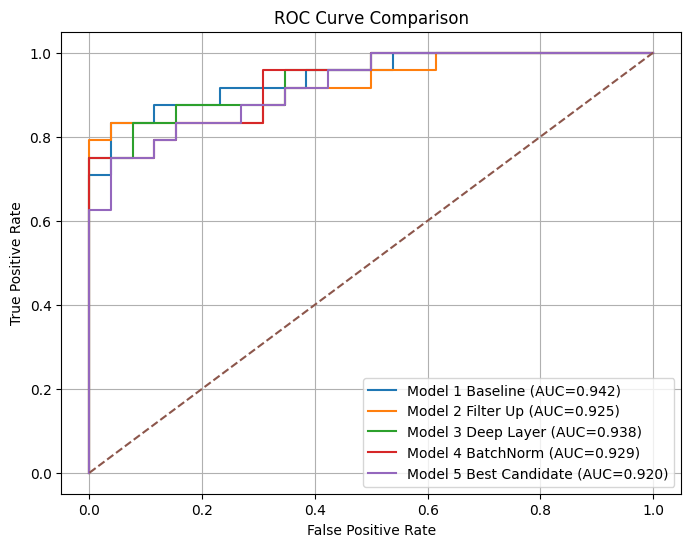

<Figure size 500x500 with 0 Axes>

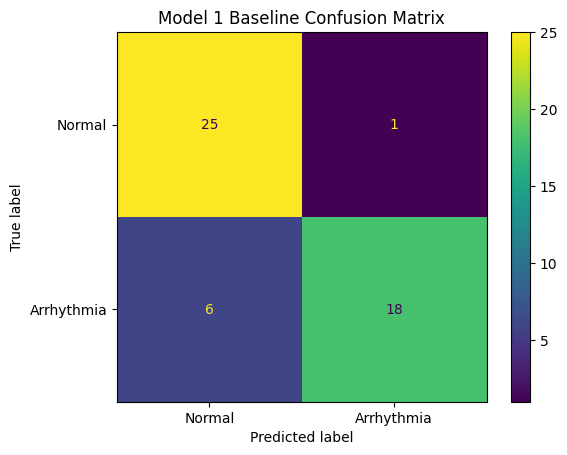

<Figure size 500x500 with 0 Axes>

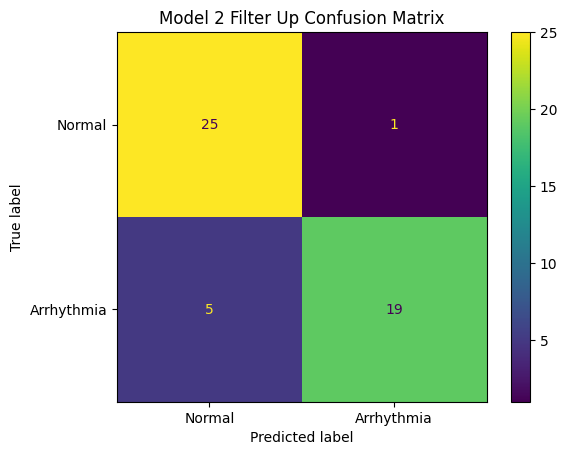

<Figure size 500x500 with 0 Axes>

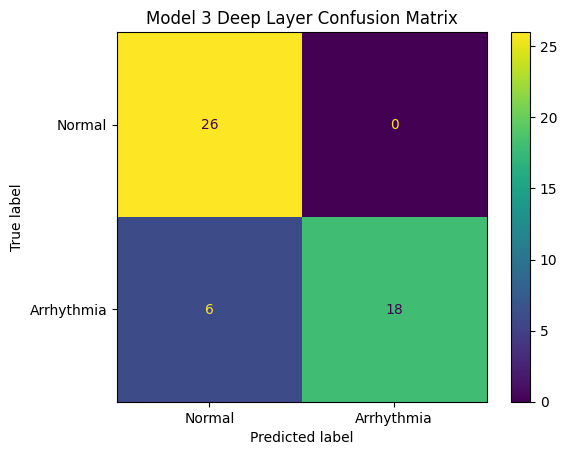

<Figure size 500x500 with 0 Axes>

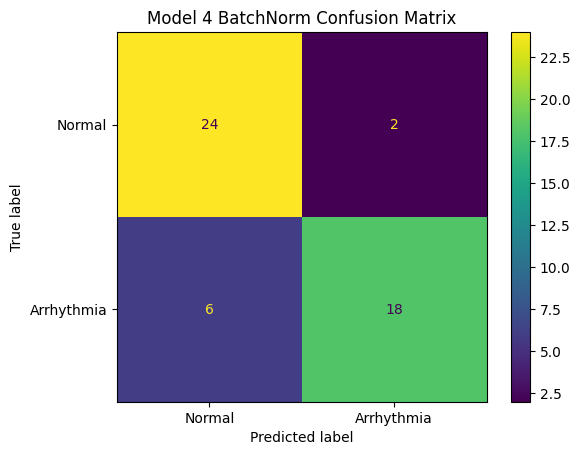

<Figure size 500x500 with 0 Axes>

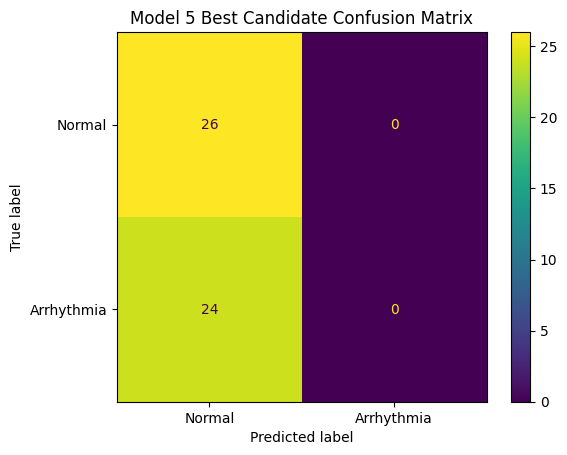


========== FINAL RESULT ==========

Model 1 Baseline
Accuracy    : 0.8600
Precision   : 0.9474
Sensitivity : 0.7500
F1-score    : 0.8372
AUC         : 0.9423
Final Score : 0.8641

Model 2 Filter Up
Accuracy    : 0.8800
Precision   : 0.9500
Sensitivity : 0.7917
F1-score    : 0.8636
AUC         : 0.9247
Final Score : 0.8753

Model 3 Deep Layer
Accuracy    : 0.8800
Precision   : 1.0000
Sensitivity : 0.7500
F1-score    : 0.8571
AUC         : 0.9375
Final Score : 0.8701

Model 4 BatchNorm
Accuracy    : 0.8400
Precision   : 0.9000
Sensitivity : 0.7500
F1-score    : 0.8182
AUC         : 0.9295
Final Score : 0.8512

Model 5 Best Candidate
Accuracy    : 0.5200
Precision   : 0.0000
Sensitivity : 0.0000
F1-score    : 0.0000
AUC         : 0.9199
Final Score : 0.4199

Best Model : Model 2 Filter Up
Accuracy    : 0.8800
Precision   : 0.9500
Sensitivity : 0.7917
F1-score    : 0.8636
AUC         : 0.9247
Final Score : 0.8753
최고 성능 모델 저장 완료
저장된 모델: Model 2 Filter Up


In [12]:
# =========================================================
# CNN 모델 5개 비교 + ROC Curve + AUC + 혼동행렬
# =========================================================

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    Dropout,
    Dense,
    GlobalAveragePooling1D,
    BatchNormalization
)

from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# 랜덤 시드 고정
# =========================================================
np.random.seed(42)
tf.random.set_seed(42)

# =========================================================
# 데이터 로드
# =========================================================
X = np.load("X_ecg.npy")
y = np.load("y_ecg.npy")

print("원본 X shape:", X.shape)
print("원본 y shape:", y.shape)

# 정규화
X = (X - X.mean(axis=1, keepdims=True)) / (
    X.std(axis=1, keepdims=True) + 1e-8
)

# Conv1D 입력 형태
X = X.reshape(X.shape[0], X.shape[1], 1)

print("변환 X shape:", X.shape)

# Train / Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================================================
# Class Weight
# =========================================================
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight = {
    classes[i]: class_weights[i]
    for i in range(len(classes))
}

print("Class Weight:", class_weight)

# =========================================================
# 모델 생성 함수
# =========================================================
def build_model(model_type):

    model = Sequential()

    # -----------------------------------------------------
    # Model 1 : Baseline
    # -----------------------------------------------------
    if model_type == "baseline":

        model.add(Conv1D(
            16,
            kernel_size=21,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001),
            input_shape=(X.shape[1], 1)
        ))
        model.add(MaxPooling1D(8))
        model.add(Dropout(0.2))

        model.add(Conv1D(
            32,
            kernel_size=15,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(4))
        model.add(Dropout(0.25))

        model.add(Conv1D(
            64,
            kernel_size=9,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.3))

        dense_units = 32
        dense_dropout = 0.3
        lr = 0.0003

    # -----------------------------------------------------
    # Model 2 : Filter Up
    # -----------------------------------------------------
    elif model_type == "filter_up":

        model.add(Conv1D(
            32,
            kernel_size=21,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001),
            input_shape=(X.shape[1], 1)
        ))
        model.add(MaxPooling1D(8))
        model.add(Dropout(0.2))

        model.add(Conv1D(
            64,
            kernel_size=15,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(4))
        model.add(Dropout(0.25))

        model.add(Conv1D(
            128,
            kernel_size=9,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.3))

        dense_units = 32
        dense_dropout = 0.3
        lr = 0.0003

    # -----------------------------------------------------
    # Model 3 : Deep Layer
    # -----------------------------------------------------
    elif model_type == "deep_layer":

        model.add(Conv1D(
            16,
            kernel_size=21,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001),
            input_shape=(X.shape[1], 1)
        ))
        model.add(MaxPooling1D(8))
        model.add(Dropout(0.2))

        model.add(Conv1D(
            32,
            kernel_size=15,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(4))
        model.add(Dropout(0.25))

        model.add(Conv1D(
            64,
            kernel_size=9,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.3))

        model.add(Conv1D(
            128,
            kernel_size=5,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.35))

        dense_units = 32
        dense_dropout = 0.3
        lr = 0.0003

    # -----------------------------------------------------
    # Model 4 : BatchNorm
    # -----------------------------------------------------
    elif model_type == "batchnorm":

        model.add(Conv1D(
            32,
            kernel_size=21,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001),
            input_shape=(X.shape[1], 1)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(8))
        model.add(Dropout(0.2))

        model.add(Conv1D(
            64,
            kernel_size=15,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(4))
        model.add(Dropout(0.25))

        model.add(Conv1D(
            128,
            kernel_size=9,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.3))

        dense_units = 32
        dense_dropout = 0.3
        lr = 0.0003

    # -----------------------------------------------------
    # Model 5 : Best Candidate
    # -----------------------------------------------------
    elif model_type == "best_candidate":

        model.add(Conv1D(
            32,
            kernel_size=31,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001),
            input_shape=(X.shape[1], 1)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(8))
        model.add(Dropout(0.25))

        model.add(Conv1D(
            64,
            kernel_size=21,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(4))
        model.add(Dropout(0.3))

        model.add(Conv1D(
            128,
            kernel_size=11,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.35))

        model.add(Conv1D(
            256,
            kernel_size=5,
            activation="relu",
            padding="same",
            kernel_regularizer=l2(0.001)
        ))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(2))
        model.add(Dropout(0.4))

        dense_units = 32
        dense_dropout = 0.3
        lr = 0.0003

    # =====================================================
    # 공통 구조
    # =====================================================
    model.add(GlobalAveragePooling1D())

    model.add(Dense(
        dense_units,
        activation="relu",
        kernel_regularizer=l2(0.001)
    ))

    model.add(Dropout(dense_dropout))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

# =========================================================
# 모델 목록
# =========================================================
models = {
    "Model 1 Baseline": "baseline",
    "Model 2 Filter Up": "filter_up",
    "Model 3 Deep Layer": "deep_layer",
    "Model 4 BatchNorm": "batchnorm",
    "Model 5 Best Candidate": "best_candidate"
}

epoch_dict = {
    "Model 1 Baseline": 100,
    "Model 2 Filter Up": 100,
    "Model 3 Deep Layer": 100,
    "Model 4 BatchNorm": 100,
    "Model 5 Best Candidate": 100
}

results = {}

# =========================================================
# 모델 학습
# =========================================================
for name, model_type in models.items():

    print(f"\n========== {name} ==========")

    model = build_model(model_type)

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True
    )

    reduce_lr = ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=0.00001
    )

    history = model.fit(
        X_train,
        y_train,
        epochs=epoch_dict[name],
        batch_size=8,
        validation_split=0.2,
        class_weight=class_weight,
        callbacks=[early_stop, reduce_lr],
        verbose=1
    )

    y_prob = model.predict(X_test).ravel()

    # 3개 모델 코드 기준 threshold
    threshold = 0.65

    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    sensitivity = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_prob)

    # 3개 모델 코드 기준 final score
    final_score = (
        auc * 0.4 +
        f1 * 0.3 +
        sensitivity * 0.2 +
        acc * 0.1
    )

    results[name] = {
        "model": model,
        "history": history,
        "acc": acc,
        "precision": precision,
        "sensitivity": sensitivity,
        "f1": f1,
        "auc": auc,
        "cm": cm,
        "fpr": fpr,
        "tpr": tpr,
        "final_score": final_score
    }

    print(f"Accuracy    : {acc:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Sensitivity : {sensitivity:.4f}")
    print(f"F1-score    : {f1:.4f}")
    print(f"AUC         : {auc:.4f}")
    print(f"Final Score : {final_score:.4f}")

# =========================================================
# ROC Curve 비교
# =========================================================
plt.figure(figsize=(8, 6))

for name in results:
    plt.plot(
        results[name]["fpr"],
        results[name]["tpr"],
        label=f"{name} (AUC={results[name]['auc']:.3f})"
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 혼동행렬 시각화
# =========================================================
for name in results:

    plt.figure(figsize=(5, 5))

    disp = ConfusionMatrixDisplay(
        confusion_matrix=results[name]["cm"],
        display_labels=["Normal", "Arrhythmia"]
    )

    disp.plot(values_format="d")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

# =========================================================
# 최종 성능 비교
# =========================================================
print("\n========== FINAL RESULT ==========")

for name in results:

    print(f"\n{name}")
    print(f"Accuracy    : {results[name]['acc']:.4f}")
    print(f"Precision   : {results[name]['precision']:.4f}")
    print(f"Sensitivity : {results[name]['sensitivity']:.4f}")
    print(f"F1-score    : {results[name]['f1']:.4f}")
    print(f"AUC         : {results[name]['auc']:.4f}")
    print(f"Final Score : {results[name]['final_score']:.4f}")

# =========================================================
# 최고 성능 모델 찾기
# =========================================================
best_model = max(
    results,
    key=lambda x: results[x]["final_score"]
)

print("\n===================================")
print(f"Best Model : {best_model}")
print(f"Accuracy    : {results[best_model]['acc']:.4f}")
print(f"Precision   : {results[best_model]['precision']:.4f}")
print(f"Sensitivity : {results[best_model]['sensitivity']:.4f}")
print(f"F1-score    : {results[best_model]['f1']:.4f}")
print(f"AUC         : {results[best_model]['auc']:.4f}")
print(f"Final Score : {results[best_model]['final_score']:.4f}")
print("===================================")

# =========================================================
# 최고 성능 모델 저장
# =========================================================
best_model_object = results[best_model]["model"]
best_model_object.save("ecg_cnn_10sec_tuned.keras")

print("최고 성능 모델 저장 완료")
print("저장된 모델:", best_model)